### Data profiling


In [95]:
import pandas as pd

df = pd.read_csv('data/SuperMarket.csv')

In [96]:
## Column names and data types
df.dtypes

Invoice ID                     str
Branch                         str
City                           str
Customer type                  str
Gender                         str
Product line                   str
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                          str
Date                           str
Time                           str
Payment                        str
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [97]:
df.isnull().sum()

Invoice ID                  0
Branch                      0
City                        0
Customer type               0
Gender                      0
Product line                0
Unit price                 24
Quantity                    0
Tax 5%                      0
Sales                      20
Date                       12
Time                        0
Payment                     0
cogs                        0
gross margin percentage     0
gross income                0
Rating                      0
dtype: int64

In [98]:
df.duplicated().sum()

np.int64(14)

In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1014 non-null   str    
 1   Branch                   1014 non-null   str    
 2   City                     1014 non-null   str    
 3   Customer type            1014 non-null   str    
 4   Gender                   1014 non-null   str    
 5   Product line             1014 non-null   str    
 6   Unit price               990 non-null    float64
 7   Quantity                 1014 non-null   int64  
 8   Tax 5%                   1014 non-null   float64
 9   Sales                    994 non-null    str    
 10  Date                     1002 non-null   str    
 11  Time                     1014 non-null   str    
 12  Payment                  1014 non-null   str    
 13  cogs                     1014 non-null   float64
 14  gross margin percentage  1014 non-n

In [100]:
df.describe()

,Unit price,Quantity,Tax 5%,cogs,gross margin percentage,gross income,Rating
count,990.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,55.520333,5.502959,15.336872,306.737436,4.761905,15.336872,6.960454
std,26.330508,2.927133,11.685945,233.718896,0.000000,11.685945,1.721264
min,10.080000,1.000000,0.508500,10.170000,4.761905,0.508500,4.000000
25%,33.202500,3.000000,5.864625,117.292500,4.761905,5.864625,5.500000
50%,54.890000,5.000000,12.066000,241.320000,4.761905,12.066000,6.900000
75%,77.667500,8.000000,22.428000,448.560000,4.761905,22.428000,8.475000
max,99.960000,10.000000,49.650000,993.000000,4.761905,49.650000,10.000000


In [101]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.22,3/8/2019,10:29:00,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23:00,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.048,1/27/2019,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,NaN,10:37:00,E-wallet,604.17,4.761905,30.2085,5.3


### Unnecessary data is the ID column , will check duplicates and sum values

In [102]:
# renaming columns using clear and readable names

df.rename(columns={'Invoice ID': 'Invoice_ID','Customer type': 'Customer_type',
                   'Product line': 'Product_line', 'Unit price': 'Unit_price',
                   'Tax 5%': 'Tax_5_percent','gross margin percentage': 'gross_margin_percentage',
                   'gross income': 'gross_income'}, inplace=True)


In [103]:
# Handling missing values when necessary
# Filling null values with predective values

# Convert numeric columns to numeric types
df['Unit_price'] = pd.to_numeric(df['Unit_price'], errors='coerce')
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

# Fill numerical missing values with median
df['Unit_price'] = df['Unit_price'].fillna(df['Unit_price'].median())
df['Sales'] = df['Sales'].fillna(df['Sales'].median())

# Convert Date to datetime
df['Date'] = pd.to_datetime(
    df['Date'],
    format='mixed',
    dayfirst=False,
    errors='coerce'
)

# Remove rows where Date is missing because
# date-based analysis cannot be performed on them
df.dropna(subset=['Date'], inplace=True)


In [104]:
#removing duplicate rows

df.drop_duplicates(inplace=True)

In [105]:
# Remove unnecessary columns that are not needed for analysis

df.drop(columns=['Invoice_ID'], inplace=True)

In [106]:
#Make sure that the data types of the columns are appropriate for analysis
#date is string while it should be datetime, so we will convert it to datetime

df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=False)
df.info()

<class 'pandas.DataFrame'>
Index: 988 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Branch                   988 non-null    str           
 1   City                     988 non-null    str           
 2   Customer_type            988 non-null    str           
 3   Gender                   988 non-null    str           
 4   Product_line             988 non-null    str           
 5   Unit_price               988 non-null    float64       
 6   Quantity                 988 non-null    int64         
 7   Tax_5_percent            988 non-null    float64       
 8   Sales                    988 non-null    float64       
 9   Date                     988 non-null    datetime64[us]
 10  Time                     988 non-null    str           
 11  Payment                  988 non-null    str           
 12  cogs                     988 non-null    float64    

In [107]:
#sorting the data by date to make it easier to analyze trends over time

df.sort_values(by='Date', inplace=True)

In [108]:
#Creating new features/columns Day,Month,Year

df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df.head()

,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Tax_5_percent,Sales,Date,Time,Payment,cogs,gross_margin_percentage,gross_income,Rating,Day,Month,Year
970,Cairo,Mandalay,Member,Female,Food and beverages,84.63,10,42.315,888.615,2019-01-01,11:36:00,Credit card,846.30,4.761905,42.315,9.0,1,1,2019
696,Alex,Yangon,Member,Female,Sports and travel,27.04,4,5.408,113.568,2019-01-01,20:26:00,Ewallet,108.16,4.761905,5.408,6.9,1,1,2019
567,Alex,Yangon,Normal,Female,Fashion accessories,65.74,9,29.583,621.243,2019-01-01,13:55:00,Cash,591.66,4.761905,29.583,7.7,1,1,2019
17,Alex,Yangon,Member,Female,Sports and travel,72.61,6,21.783,457.443,2019-01-01,10:39:00,Credit card,435.66,4.761905,21.783,6.9,1,1,2019
856,Cairo,Mandalay,Normal,Male,Food and beverages,21.12,8,8.448,177.408,2019-01-01,19:31:00,Cash,168.96,4.761905,8.448,6.3,1,1,2019


In [109]:
#Creating new column called satisfied based on rating

df['satisfied'] = df['Rating'].apply(lambda x: 'satisfied' if x >= 7 else 'not satisfied')

df.head()

,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Tax_5_percent,Sales,Date,Time,Payment,cogs,gross_margin_percentage,gross_income,Rating,Day,Month,Year,satisfied
970,Cairo,Mandalay,Member,Female,Food and beverages,84.63,10,42.315,888.615,2019-01-01,11:36:00,Credit card,846.30,4.761905,42.315,9.0,1,1,2019,satisfied
696,Alex,Yangon,Member,Female,Sports and travel,27.04,4,5.408,113.568,2019-01-01,20:26:00,Ewallet,108.16,4.761905,5.408,6.9,1,1,2019,not satisfied
567,Alex,Yangon,Normal,Female,Fashion accessories,65.74,9,29.583,621.243,2019-01-01,13:55:00,Cash,591.66,4.761905,29.583,7.7,1,1,2019,satisfied
17,Alex,Yangon,Member,Female,Sports and travel,72.61,6,21.783,457.443,2019-01-01,10:39:00,Credit card,435.66,4.761905,21.783,6.9,1,1,2019,not satisfied
856,Cairo,Mandalay,Normal,Male,Food and beverages,21.12,8,8.448,177.408,2019-01-01,19:31:00,Cash,168.96,4.761905,8.448,6.3,1,1,2019,not satisfied


In [110]:
# Convert Sales to numeric
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

# Fill missing Sales values
df['Sales'].fillna(df['Sales'].mean(), inplace=True)

C:\Users\Hassan-PC\AppData\Local\Temp\ipykernel_23988\3178466821.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Sales'].fillna(df['Sales'].mean(), inplace=True)


970    888.615
696    113.568
567    621.243
17     457.443
856    177.408
        ...   
158    918.729
646    442.323
963    304.983
671    196.140
937    469.770
Name: Sales, Length: 988, dtype: float64

### Data analysis

In [111]:
import matplotlib.pyplot as plt

Total Revenue: $313,909.75


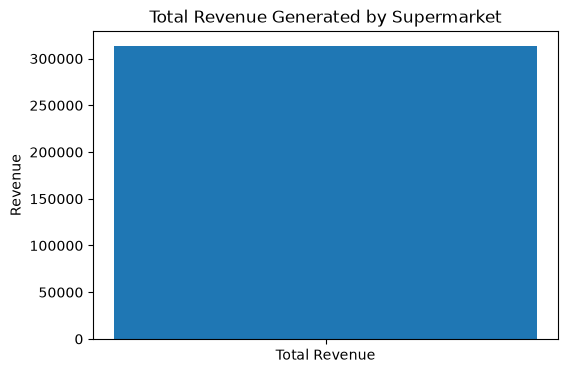

In [112]:
# 1. Total revenue generated by the supermarket

total_revenue = df['Sales'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

plt.figure(figsize=(6, 4))
plt.bar(['Total Revenue'], [total_revenue])
plt.ylabel('Revenue')
plt.title('Total Revenue Generated by Supermarket')
plt.show()

Revenue by City:
City
Naypyitaw    107792.5380
Mandalay     103736.1465
Yangon       102381.0690
Name: Sales, dtype: float64

City with highest revenue: Naypyitaw
Revenue: $107,792.54


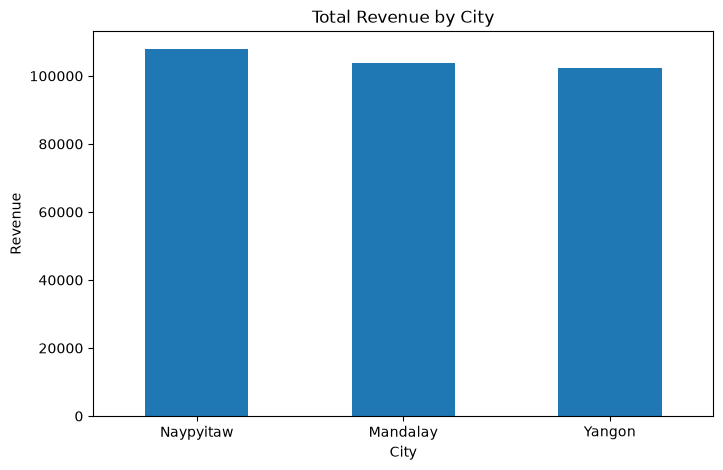

In [113]:
# 2. Total revenue by city
revenue_by_city = (df.groupby('City')['Sales'].sum().sort_values(ascending=False))
print(f"Revenue by City:\n{revenue_by_city}")
highest_revenue_city = revenue_by_city.idxmax()
highest_city_revenue = revenue_by_city.max()

print(f"\nCity with highest revenue: {highest_revenue_city}")
print(f"Revenue: ${highest_city_revenue:,.2f}")

# Visualization
plt.figure(figsize=(8, 5))
revenue_by_city.plot(kind='bar')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.title('Total Revenue by City')
plt.xticks(rotation=0)
plt.show()

Profit by Branch:
Branch
Giza     5187.1100
Cairo    4977.8220
Alex     4933.6515
cairo      34.8700
giza       11.4000
Name: gross_income, dtype: float64

Most profitable branch: Giza
Profit: $5,187.11


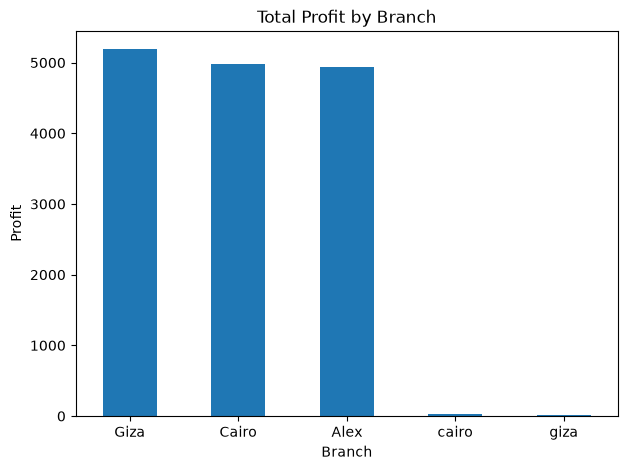

In [114]:
# 3. Total profit by branch

profit_by_branch = (df.groupby('Branch')['gross_income'].sum().sort_values(ascending=False))
print(f"Profit by Branch:\n{profit_by_branch}")
most_profitable_branch = profit_by_branch.idxmax()
highest_branch_profit = profit_by_branch.max()

print(f"\nMost profitable branch: {most_profitable_branch}")
print(f"Profit: ${highest_branch_profit:,.2f}")

# Visualization
plt.figure(figsize=(7, 5))
profit_by_branch.plot(kind='bar')
plt.xlabel('Branch')
plt.ylabel('Profit')
plt.title('Total Profit by Branch')
plt.xticks(rotation=0)
plt.show()

In [115]:
# 4. Revenue and profit by product category
category_performance = (df.groupby('Product_line').agg(Revenue=('Sales', 'sum'),Profit=('gross_income', 'sum')).sort_values('Revenue', ascending=False))
print(f"Revenue and Profit by Product Category:\n{category_performance}")
top_category = category_performance['Revenue'].idxmax()
print(f"\nTop-performing category: {top_category}")
print(f"Revenue: ${category_performance.loc[top_category, 'Revenue']:,.2f}")
print(f"Profit: ${category_performance.loc[top_category, 'Profit']:,.2f}")

Revenue and Profit by Product Category:
                           Revenue     Profit
Product_line                                 
Food and beverages      55019.8425  2643.7430
Sports and travel       53319.6195  2566.5720
Fashion accessories     53197.4730  2583.0990
Electronic accessories  52650.3810  2520.1235
Home and lifestyle      51925.3035  2528.0730
Health and beauty       47797.1340  2303.2430

Top-performing category: Food and beverages
Revenue: $55,019.84
Profit: $2,643.74


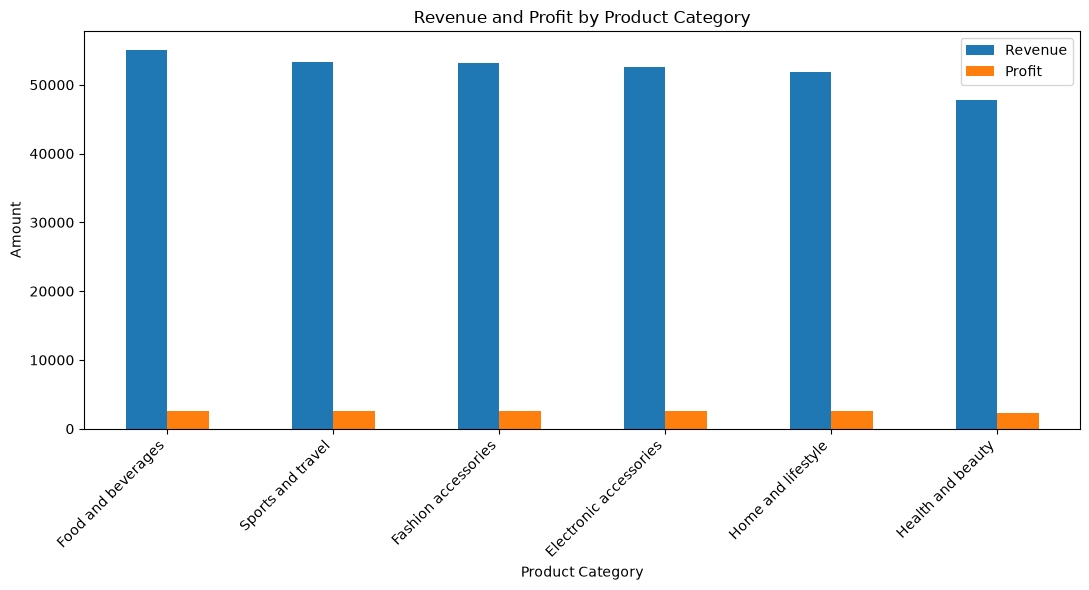

In [116]:
# Visualization

category_performance[['Revenue', 'Profit']].plot(kind='bar',figsize=(11, 6))
plt.xlabel('Product Category')
plt.ylabel('Amount')
plt.title('Revenue and Profit by Product Category')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

Total Spending by Customer Type:
Customer_type
Member    180637.7685
Normal    133271.9850
Name: Sales, dtype: float64

Customer type that spends more: Member
Total spending: $180,637.77


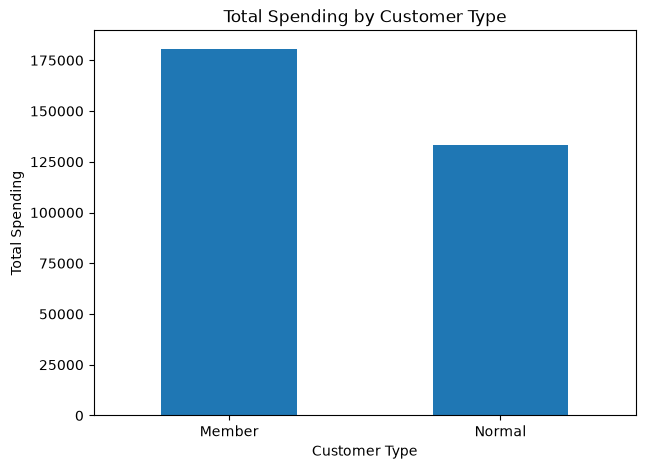

In [117]:
# 5. Total spending by customer type

spending_by_customer = (df.groupby('Customer_type')['Sales'].sum().sort_values(ascending=False))
print(f"Total Spending by Customer Type:\n{spending_by_customer}")

top_customer_type = spending_by_customer.idxmax()
top_customer_spending = spending_by_customer.max()

print(f"\nCustomer type that spends more: {top_customer_type}")
print(f"Total spending: ${top_customer_spending:,.2f}")

# Visualization
plt.figure(figsize=(7, 5))
spending_by_customer.plot(kind='bar')
plt.xlabel('Customer Type')
plt.ylabel('Total Spending')
plt.title('Total Spending by Customer Type')
plt.xticks(rotation=0)
plt.show()

Transactions by Payment Method:
Payment
cash           341
ewallet        338
credit card    309
Name: count, dtype: int64

Most popular payment method: cash
Number of transactions: 341


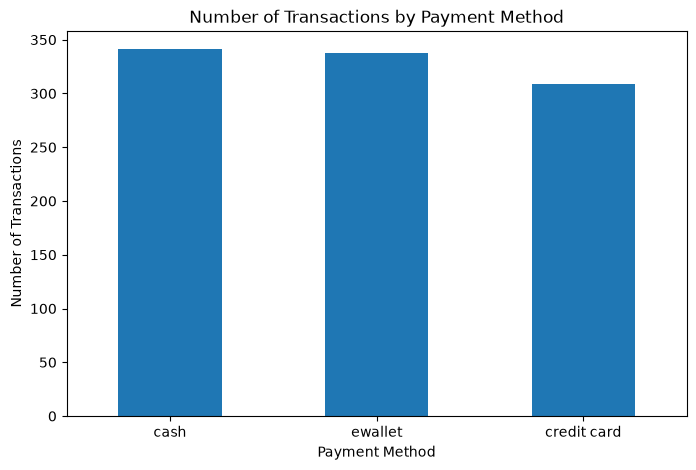

In [118]:
# 6. Number of transactions by payment method

df['Payment'] = (df['Payment'].str.strip().str.lower().replace({'e-wallet': 'ewallet','e wallet': 'ewallet'}))

transactions_by_payment = (df['Payment'].value_counts())

print(f"Transactions by Payment Method:\n{transactions_by_payment}")

most_popular_payment = transactions_by_payment.idxmax()
most_popular_payment_count = transactions_by_payment.max()

print(f"\nMost popular payment method: {most_popular_payment}")
print(f"Number of transactions: {most_popular_payment_count}")

# Visualization
plt.figure(figsize=(8, 5))
transactions_by_payment.plot(kind='bar')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.title('Number of Transactions by Payment Method')
plt.xticks(rotation=0)
plt.show()

In [119]:
# 7. Average transaction value

average_transaction_value = df['Sales'].mean()

print(f"Average Transaction Value: ${average_transaction_value:,.2f}")

Average Transaction Value: $317.72


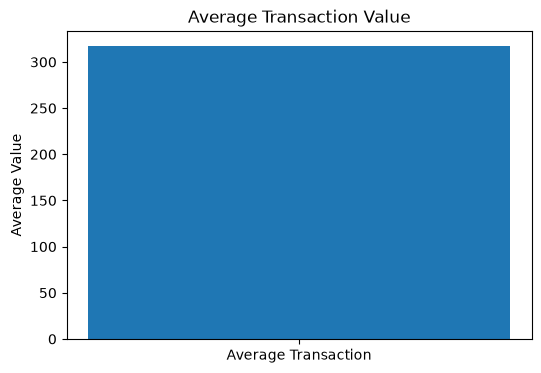

In [120]:
plt.figure(figsize=(6, 4))
plt.bar(['Average Transaction'], [average_transaction_value])
plt.ylabel('Average Value')
plt.title('Average Transaction Value')
plt.show()

Customer Satisfaction Percentage by Branch:
Branch
cairo    100.00
Alex      52.69
Giza      52.31
Cairo     45.87
giza       0.00
Name: satisfied, dtype: float64

Branch with highest satisfaction: cairo
Satisfaction: 100.00%


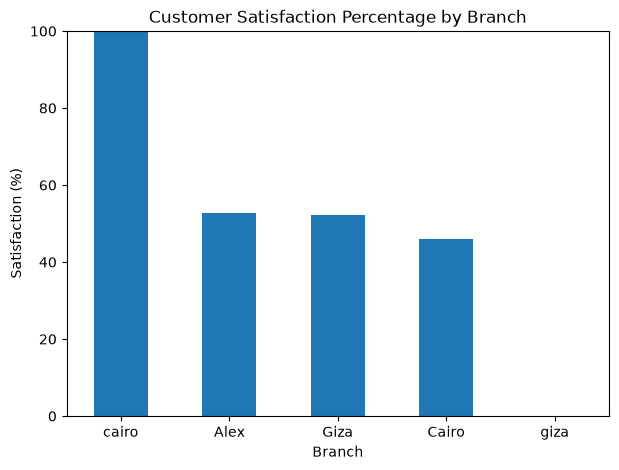

In [121]:
# 8. Customer satisfaction percentage by branch
satisfaction_by_branch = (df.groupby('Branch')['satisfied'].apply(lambda x: (x == 'satisfied').mean() * 100).sort_values(ascending=False))
print(f"Customer Satisfaction Percentage by Branch:\n{satisfaction_by_branch.round(2)}")
highest_satisfaction_branch = satisfaction_by_branch.idxmax()
highest_satisfaction_percentage = satisfaction_by_branch.max()

print(
    f"\nBranch with highest satisfaction: "
    f"{highest_satisfaction_branch}"
)

print(
    f"Satisfaction: "
    f"{highest_satisfaction_percentage:.2f}%"
)

# Visualization
plt.figure(figsize=(7, 5))
satisfaction_by_branch.plot(kind='bar')
plt.xlabel('Branch')
plt.ylabel('Satisfaction (%)')
plt.title('Customer Satisfaction Percentage by Branch')
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.show()

Revenue by Day of Month:
Day
1      9370.2945
2     12880.7700
3     12132.0780
4      7957.6245
5     12631.3635
6      9111.4065
7     10186.1550
8     13020.6405
9     13609.9950
10     9972.0285
11     9219.3675
12    11675.2335
13     5535.6735
14    13570.4940
15    15302.3535
16     9947.3220
17    10418.6145
18     5569.3365
19    14883.2355
20    11140.9095
21     5663.3535
22     6873.8565
23    12515.9160
24    10157.9310
25    10719.2610
26     9030.3045
27    13558.3140
28     8857.1595
29     6120.9435
30     7045.3215
31     5232.4965
Name: Sales, dtype: float64

Day of month with highest sales: 15
Revenue: $15,302.35


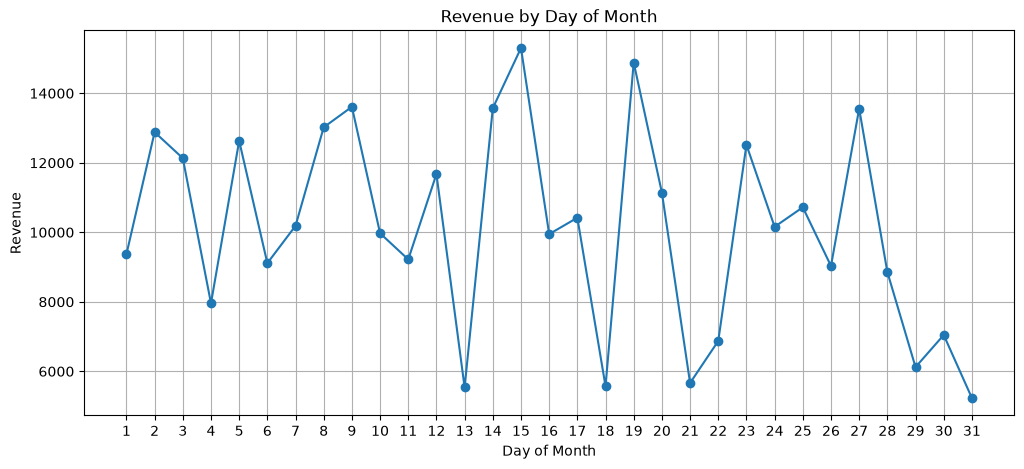

In [122]:
# 9A. Revenue by day of the month
revenue_by_day = (df.groupby('Day')['Sales'].sum().sort_values(ascending=False))
highest_sales_day = revenue_by_day.idxmax()
highest_day_revenue = revenue_by_day.max()

print(f"Revenue by Day of Month:\n{revenue_by_day.sort_index()}")
print(
    f"\nDay of month with highest sales: "
    f"{highest_sales_day}"
)
print(
    f"Revenue: ${highest_day_revenue:,.2f}"
)
# Visualization
plt.figure(figsize=(12, 5))
revenue_by_day.sort_index().plot(kind='line', marker='o')
plt.xlabel('Day of Month')
plt.ylabel('Revenue')
plt.title('Revenue by Day of Month')
plt.xticks(range(1, 32))
plt.grid(True)
plt.show()

Revenue by Day of Week:
Day_of_week
Monday       36077.0865
Tuesday      50288.1540
Wednesday    43990.6215
Thursday     43212.5820
Friday       41745.8790
Saturday     56284.6305
Sunday       42310.8000
Name: Sales, dtype: float64

Day of week with highest sales: Saturday
Revenue: $56,284.63


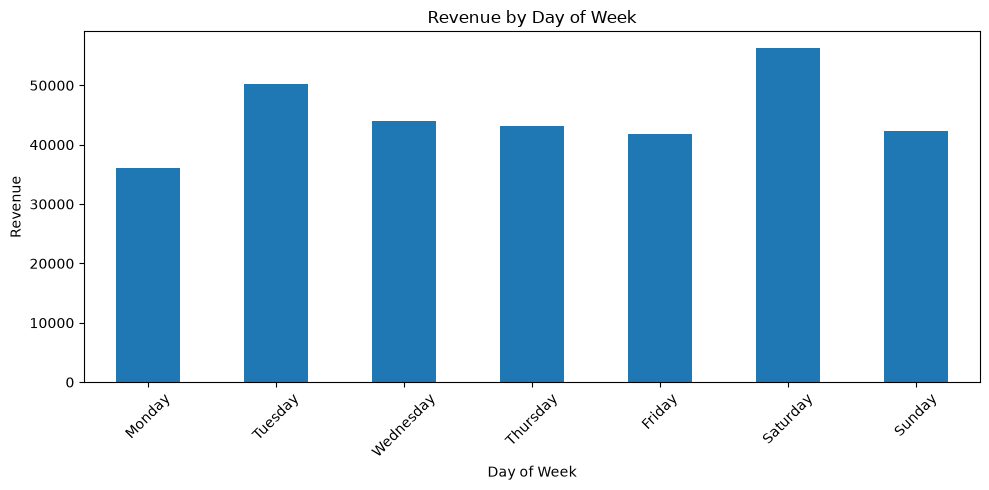

In [123]:
# 9B. Revenue by day of week
df['Day_of_week'] = df['Date'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
revenue_by_weekday = (df.groupby('Day_of_week')['Sales'].sum().reindex(day_order))
highest_sales_weekday = revenue_by_weekday.idxmax()
highest_weekday_revenue = revenue_by_weekday.max()

print("Revenue by Day of Week:")
print(revenue_by_weekday)

print(
    f"\nDay of week with highest sales: "
    f"{highest_sales_weekday}"
)

print(
    f"Revenue: ${highest_weekday_revenue:,.2f}"
)

# Visualization
plt.figure(figsize=(10, 5))
revenue_by_weekday.plot(kind='bar')
plt.xlabel('Day of Week')
plt.ylabel('Revenue')
plt.title('Revenue by Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Revenue by Month:
Month
1    113044.7115
2     93609.6000
3    107255.4420
Name: Sales, dtype: float64

Month with highest sales: 1
Revenue: $113,044.71


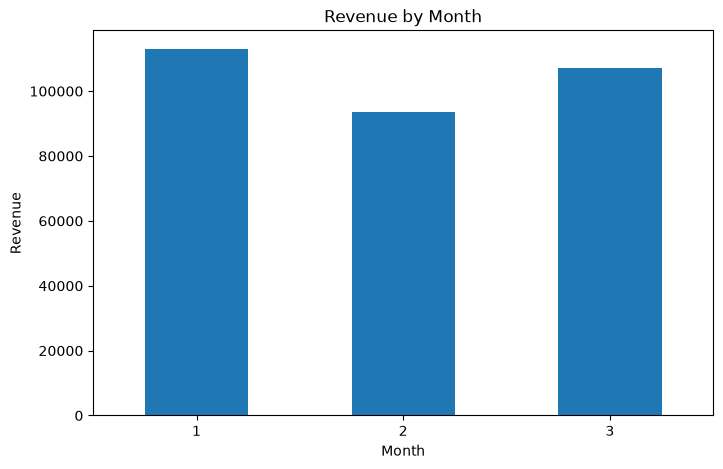

In [124]:
# 9C. Revenue by month

revenue_by_month = (df.groupby('Month')['Sales'].sum().sort_index())

highest_sales_month = revenue_by_month.idxmax()
highest_month_revenue = revenue_by_month.max()

print(f"Revenue by Month:\n{revenue_by_month}")
print(
    f"\nMonth with highest sales: "
    f"{highest_sales_month}"
)

print(
    f"Revenue: ${highest_month_revenue:,.2f}"
)

# Visualization
plt.figure(figsize=(8, 5))
revenue_by_month.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Revenue by Month')
plt.xticks(rotation=0)
plt.show()

In [125]:
# 10. Overall percentage of satisfied customers/transactions
satisfaction_percentage = ((df['satisfied'] == 'satisfied').mean() * 100)
print(
    f"Overall Customer Satisfaction: "
    f"{satisfaction_percentage:.2f}%"
)

Overall Customer Satisfaction: 50.30%


In [126]:
satisfaction_counts = df['satisfied'].value_counts()
print(f"Satisfaction Counts:\n{satisfaction_counts}")
print(f"\nOverall Satisfaction: {satisfaction_percentage:.2f}%")

Satisfaction Counts:
satisfied
satisfied        497
not satisfied    491
Name: count, dtype: int64

Overall Satisfaction: 50.30%


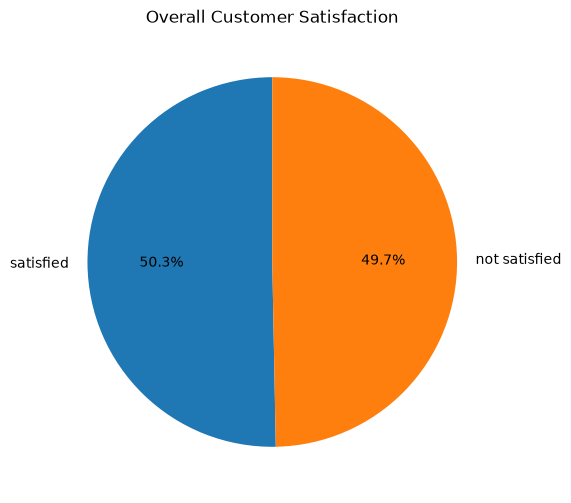

In [127]:
plt.figure(figsize=(6, 6))
satisfaction_counts.plot(kind='pie',autopct='%1.1f%%',startangle=90)
plt.ylabel('')
plt.title('Overall Customer Satisfaction')
plt.show()